In [2]:
import os

PROJECT_ROOT = r"C:\Users\nicol\OneDrive\Bureau\Finance"
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

Current working directory: C:\Users\nicol\OneDrive\Bureau\Finance


In [3]:
import pandas as pd

df = pd.read_csv("data/processed/features.csv")
df.head()

,Date,Open,High,Low,Close,Volume,log_return,vol_5,vol_10,vol_21,vol_ewma,ATR,RSI,MACD,MACD_signal,log_volume,volume_change,target_vol
0,2015-02-03 00:00:00-05:00,2022.709961,2050.300049,2022.709961,2050.030029,4615900000,0.014336,0.014115,0.011876,0.011401,0.011663,30.628584,54.949410,-0.174383,-0.104848,22.252773,0.141132,0.010659
1,2015-02-04 00:00:00-05:00,2048.860107,2054.739990,2036.719971,2041.510010,4141920000,-0.004165,0.011980,0.011928,0.010659,0.011154,29.445007,55.609976,0.788912,0.075233,22.144425,-0.108347,0.010632
2,2015-02-05 00:00:00-05:00,2043.449951,2063.550049,2043.449951,2062.520020,3821990000,0.010239,0.012071,0.011342,0.010632,0.010990,28.885010,62.843383,2.954017,0.654408,22.064037,-0.080388,0.010417
3,2015-02-06 00:00:00-05:00,2062.280029,2072.399902,2049.969971,2055.469971,4232970000,-0.003424,0.009040,0.011249,0.010417,0.010524,28.177150,57.146245,4.116070,1.350026,22.166170,0.102133,0.009699
4,2015-02-09 00:00:00-05:00,2053.469971,2056.159912,2041.880005,2046.739990,3549540000,-0.004256,0.009016,0.011295,0.009699,0.010109,27.450718,54.691067,4.364544,1.955216,21.990084,-0.176086,0.009796


In [4]:
import numpy as np

# Replace inf with NaN and drop rows with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Data cleaned. Shape:", df.shape)

Data cleaned. Shape: (2240, 18)


In [5]:
FEATURES = [
    "vol_5", "vol_10", "vol_21", "vol_ewma",
    "log_return"
]

TARGET = "target_vol"

In [6]:
SEQ_LENGTH = 60

In [7]:
import numpy as np

def create_sequences(X, y, seq_length):

    X_seq = []
    y_seq = []

    for i in range(seq_length, len(X)):
        X_seq.append(X[i-seq_length:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

In [ ]:
from sklearn.preprocessing import StandardScaler

X_values = df[FEATURES].copy()
y_values = df[TARGET].clip(lower=1e-8).copy()

x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X_values)

X_seq, y_seq = create_sequences(X_scaled, y_values, SEQ_LENGTH)

# safety: remove any sequences containing NaN
mask = (~np.isnan(X_seq).any(axis=(1, 2))) & (~np.isnan(y_seq))
X_seq = X_seq[mask]
y_seq = y_seq[mask]

In [ ]:
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train_raw, y_test_raw = y_seq[:split], y_seq[split:]
X_train_log = np.log(X_train + 1e-8)
X_test_log = np.log(X_test + 1e-8)

C:\Users\nicol\AppData\Local\Temp\ipykernel_14244\3248229006.py:5: RuntimeWarning: invalid value encountered in log
  X_train_log = np.log(X_train + 1e-8)
C:\Users\nicol\AppData\Local\Temp\ipykernel_14244\3248229006.py:6: RuntimeWarning: invalid value encountered in log
  X_test_log = np.log(X_test + 1e-8)


In [ ]:
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train_raw.reshape(-1, 1))
y_train_log = np.log(y_train + 1e-8)
y_test = y_scaler.transform(y_test_raw.reshape(-1, 1))

C:\Users\nicol\AppData\Local\Temp\ipykernel_14244\831089562.py:3: RuntimeWarning: invalid value encountered in log
  y_train_log = np.log(y_train + 1e-8)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

model_lstm = Sequential([
    tf.keras.layers.Input(shape=(SEQ_LENGTH, X_train.shape[2])),
    LSTM(96, return_sequences=True),
    Dropout(0.15),
    LSTM(48, return_sequences=False),
    Dropout(0.15),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss="mse"
)

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=18,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-5
)

In [13]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=220,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.7778 - val_loss: 0.0311 - learning_rate: 2.0000e-04
Epoch 2/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.3536 - val_loss: 0.0211 - learning_rate: 2.0000e-04
Epoch 3/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.2178 - val_loss: 0.0234 - learning_rate: 2.0000e-04
Epoch 4/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.1373 - val_loss: 0.0211 - learning_rate: 2.0000e-04
Epoch 5/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0857 - val_loss: 0.0203 - learning_rate: 2.0000e-04
Epoch 6/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0630 - val_loss: 0.0206 - learning_rate: 2.0000e-04
Epoch 7/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0470 - val_loss: 0.0200 - learning_rate: 2.0000e-04
Epoch 8/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0491 - val_loss: 0.0186 - learning_rate: 2.0000e-04
Epoch 9/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0467 - val_loss: 0.0182 - 

In [14]:
from tensorflow.keras.layers import GRU

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model_gru = Sequential([
    tf.keras.layers.Input(shape=(SEQ_LENGTH, X_train.shape[2])),
    GRU(96, return_sequences=True),
    Dropout(0.15),
    GRU(48, return_sequences=False),
    Dropout(0.15),
    Dense(32, activation="relu"),
    Dense(1)
])

model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss="mse"
)

history_gru = model_gru.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=220,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.5787 - val_loss: 0.0279 - learning_rate: 2.0000e-04
Epoch 2/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.2498 - val_loss: 0.0357 - learning_rate: 2.0000e-04
Epoch 3/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.1824 - val_loss: 0.0308 - learning_rate: 2.0000e-04
Epoch 4/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.1471 - val_loss: 0.0273 - learning_rate: 2.0000e-04
Epoch 5/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.1032 - val_loss: 0.0273 - learning_rate: 2.0000e-04
Epoch 6/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0771 - val_loss: 0.0254 - learning_rate: 2.0000e-04
Epoch 7/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0620 - val_loss: 0.0237 - learning_rate: 2.0000e-04
Epoch 8/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0544 - val_loss: 0.0215 - learning_rate: 1.0000e-04
Epoch 9/220
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0532 - val_loss: 0.0202 

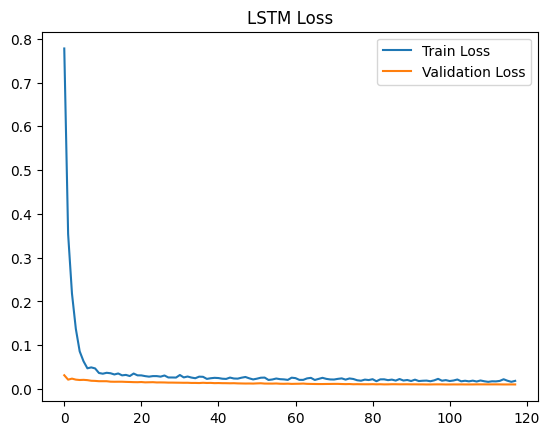

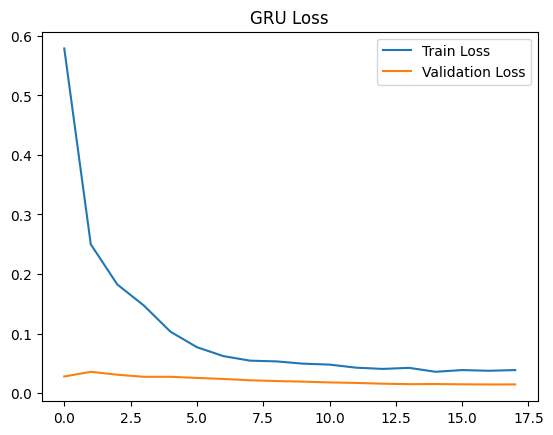

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss(history, title):
    loss = np.asarray(history.history.get("loss", []), dtype=float)
    val_loss = np.asarray(history.history.get("val_loss", []), dtype=float)
    if loss.size == 0 or np.all(~np.isfinite(loss)):
        print(f"{title}: no finite loss values to plot")
        return
    plt.figure()
    plt.plot(loss, label="Train Loss")
    if val_loss.size > 0 and np.any(np.isfinite(val_loss)):
        plt.plot(val_loss, label="Validation Loss")
    plt.title(title)
    plt.legend()
    plt.show()

plot_loss(history_lstm, "LSTM Loss")
plot_loss(history_gru, "GRU Loss")

In [16]:
from sklearn.exceptions import NotFittedError
from sklearn.preprocessing import StandardScaler
from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(y_scaler)
except (NameError, NotFittedError):
    y_scaler = StandardScaler()
    y_scaler.fit(y_train_raw.reshape(-1, 1))

y_pred_lstm_scaled = model_lstm.predict(X_test).flatten()
y_pred_gru_scaled = model_gru.predict(X_test).flatten()

y_pred_lstm = np.clip(
    y_scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten(),
    1e-8,
    None
)
y_pred_gru = np.clip(
    y_scaler.inverse_transform(y_pred_gru_scaled.reshape(-1, 1)).flatten(),
    1e-8,
    None
)

y_test_true = y_test_raw

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


In [17]:
from src.evaluation.metrics import evaluate_volatility

mask = (
    np.isfinite(y_test_true)
    & np.isfinite(y_pred_lstm)
    & np.isfinite(y_pred_gru)
)

y_true_eval = y_test_true[mask]
y_pred_lstm_eval = y_pred_lstm[mask]
y_pred_gru_eval = y_pred_gru[mask]

results_ml = {
    "LSTM": evaluate_volatility(y_true_eval, y_pred_lstm_eval),
    "GRU": evaluate_volatility(y_true_eval, y_pred_gru_eval)
}

results_ml_df = pd.DataFrame(results_ml).T
print(results_ml_df)

           MSE       MAE     QLIKE
LSTM  0.000001  0.000700 -8.079403
GRU   0.000002  0.001054 -8.067776


In [18]:
import joblib

model_lstm.save("src/models/lstm_model.keras")
joblib.dump(x_scaler, "src/models/lstm_x_scaler.pkl")
joblib.dump(y_scaler, "src/models/lstm_y_scaler.pkl")

['src/models/lstm_y_scaler.pkl']

In [19]:
model_gru.save("src/models/gru_model.keras")
joblib.dump(x_scaler, "src/models/gru_x_scaler.pkl")
joblib.dump(y_scaler, "src/models/gru_y_scaler.pkl")

['src/models/gru_y_scaler.pkl']